In [1]:
print("Hello AI 🚀")

Hello AI 🚀


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

df.head()

HTTPError: HTTP Error 404: Not Found

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/exercise.csv"
df = pd.read_csv(url)

df.head()

,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest


In [4]:
df.shape

(90, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  90 non-null     int64
 1   id          90 non-null     int64
 2   diet        90 non-null     str  
 3   pulse       90 non-null     int64
 4   time        90 non-null     str  
 5   kind        90 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.3 KB


In [6]:
X = df[['pulse']]
y = df['time']

In [7]:
df.shape

(90, 6)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  90 non-null     int64
 1   id          90 non-null     int64
 2   diet        90 non-null     str  
 3   pulse       90 non-null     int64
 4   time        90 non-null     str  
 5   kind        90 non-null     str  
dtypes: int64(3), str(3)
memory usage: 4.3 KB


In [9]:
df.columns

Index(['Unnamed: 0', 'id', 'diet', 'pulse', 'time', 'kind'], dtype='str')

In [10]:
df.describe()

,Unnamed: 0,id,pulse
count,90.000000,90.000000,90.000000
mean,44.500000,15.500000,99.700000
std,26.124701,8.703932,14.858471
min,0.000000,1.000000,80.000000
25%,22.250000,8.000000,90.250000
50%,44.500000,15.500000,96.000000
75%,66.750000,23.000000,103.000000
max,89.000000,30.000000,150.000000


In [11]:
df.isnull().sum()

Unnamed: 0    0
id            0
diet          0
pulse         0
time          0
kind          0
dtype: int64

Matplotlib is building the font cache; this may take a moment.


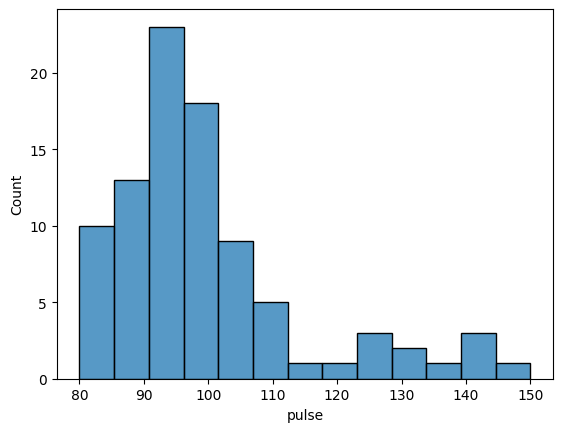

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['pulse'])
plt.show()

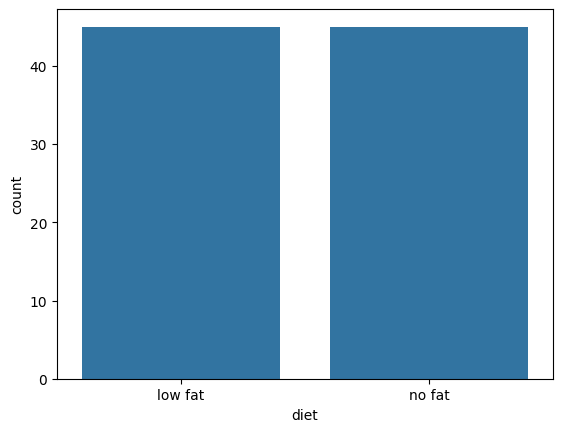

In [13]:
sns.countplot(x='diet', data=df)
plt.show()

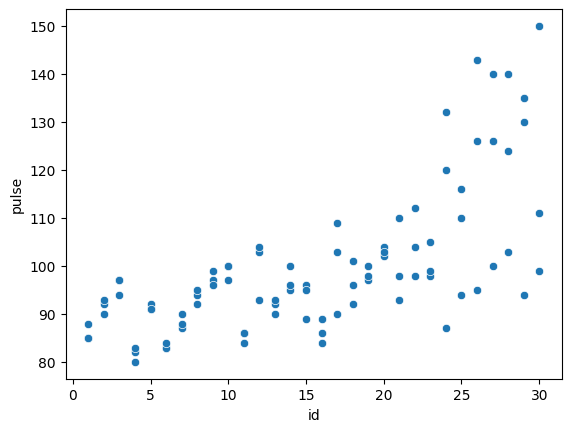

In [14]:
sns.scatterplot(x='id', y='pulse', data=df)
plt.show()

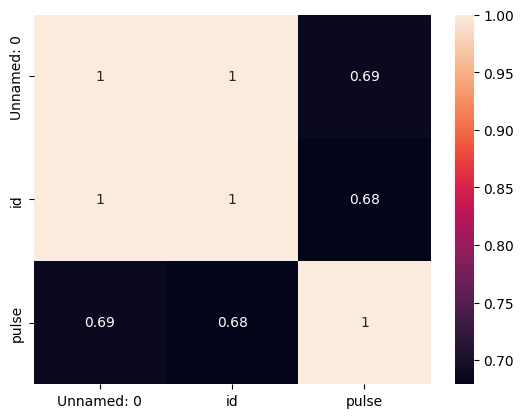

In [15]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [16]:
df['diet'] = df['diet'].map({'low fat': 0, 'no fat': 1})
df['kind'] = df['kind'].map({'rest': 0, 'walking': 1, 'running': 2})
df['time'] = df['time'].map({'1 min': 1, '15 min': 15, '30 min': 30})

In [17]:
X = df[['diet', 'time', 'kind']]
y = df['pulse']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred1 = lr.predict(X_test)

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred2 = rf.predict(X_test)

In [21]:
from sklearn.metrics import mean_squared_error, r2_score

print("Linear Regression:")
print(mean_squared_error(y_test, pred1))
print(r2_score(y_test, pred1))

print("Random Forest:")
print(mean_squared_error(y_test, pred2))
print(r2_score(y_test, pred2))

Linear Regression:
169.94473215329504
0.45281538719175995
Random Forest:
74.79827941380613
0.7591660121430102


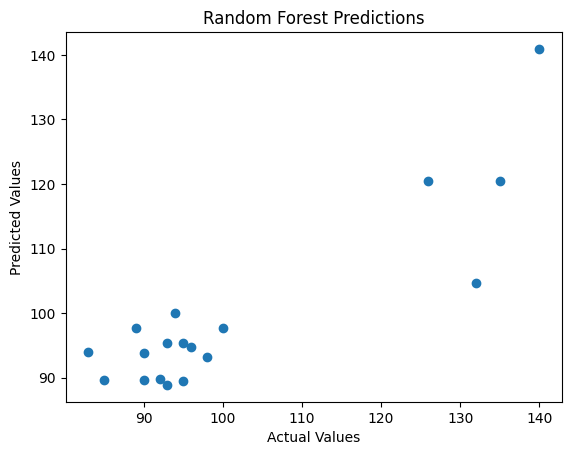

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, pred2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest Predictions")
plt.show()

In [23]:
df.to_csv("exercise.csv", index=False)